# PA3 - Neural Networks

### `Name:`

### `Roll Number:`

## Overview
In this assignment you will build and evaluate compact neural networks using the MNIST dataset (28×28 handwritten digits). The assignment covers data preprocessing, a from-scratch NumPy implementation and a PyTorch reimplementation, training and basic hyperparameter tuning, and evaluation using metrics and visualisations (accuracy, confusion matrix and example errors); make sure to read all the instructions below carefully.

<table style="width:100%; table-layout:fixed;">
<tr>
  <td style="vertical-align:top; padding:10px; width:33%;">
<h3 style="margin:0 0 6px 0; font-weight:800;">Plagiarism Policy</h3>
    <ul style="margin:6px 0 0 18px; padding:0;">
      <li><span style="color:#e53935; font-weight:700;">All work must be done independently.</span><br>
      Any plagiarism or cheating of work from others, or the internet, will be immediately referred to the DC. If you are confused about what constitutes plagiarism, consult the TAs in a timely manner.</li>
      <li style="margin-top:6px;"><span style="color:#e53935; font-weight:700;">Do not look at anyone else's code.</span></li>
    </ul>
  </td>

  <td style="vertical-align:top; padding:10px; width:33%;">
<h3 style="margin:0 0 6px 0; font-weight:800;">Submission Instructions</h3>
    <ul style="margin:6px 0 0 18px; padding:0;">
      <li>You must submit <strong>all</strong> the notebook <code>.ipynb</code> files and Python <code>.py</code> files on LMS (search how to extract scripts if confused).</li>
      <li style="margin-top:6px;"><span style="color:#e53935; font-weight:700;">Any submissions on Dropbox or email will not be entertained.</span></li>
      <li style="margin-top:6px;">Zip your files, naming it <code>Rollnumber_PAx.zip</code>. Fill in your roll number for each file.</li>
      <li style="margin-top:6px;"><span style="color:#e53935; font-weight:700;">Deviating from the naming convention will incur a penalty.</span></li>
      <li style="margin-top:6px;"><span style="color:#e53935; font-weight:700;">The file structure would look like this:</span></li>
    </ul>
    <pre style="margin:8px 0 0 0; font-size:90%;">26100076_PA3.zip
├─ 26100076_PA3.ipynb
└─ 26100076_PA3.py</pre>
  </td>

  <td style="vertical-align:top; padding:10px; width:33%;">
<h3 style="margin:0 0 6px 0; font-weight:800;">General Instructions</h3>
    <ul style="margin:6px 0 0 18px; padding:0;">
      <li><span style="color:#e53935; font-weight:700;">Make sure to run all cells for credit.</span></li>
      <li style="margin-top:6px;"><span style="color:#e53935; font-weight:700;">Do not remove any pre-written code.</span></li>
      <li style="margin-top:6px;"><span style="color:#e53935; font-weight:700;">You must attempt all parts.</span></li>
      <li style="margin-top:6px;"><span style="color:#e53935; font-weight:700;">Note that all evaluation metrics (accuracy, F1, recall) should be >=95% to get full credit in the evaluation sections.</span></li>
    </ul>
  </td>
</tr>
</table>


## Importing Libraries

All the relevant libraries have been import below. You cannot make any new imports. Do NOT modify the cell below.

In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, roc_curve, auc, classification_report
)
import random
import seaborn as sns
from PIL import Image

np.random.seed(42)

In [31]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu") # For MAC users (comment this out if you are running this locally)

## 1) Download the MNIST Dataset []

- Download the dataset using `torchvision`
- Apply any necessary transforms
- Print the size of the train and test split

In [32]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

In [33]:
print(f"Train set size: {len(dataset)}")
print(f"Test set size: {len(test_dataset)}")

Train set size: 60000
Test set size: 10000


## 2) Create Train, Test, Val Splits []

- Split the dataset using the `random_split` function
- You should have the following split:
    - Train: 50,000 samples
    - Test: 10,000 samples
    - Validation: 10,000 samples
- Load the dataset into `DataLoaders`
- Print the size of each split

In [34]:
train_size = 50000
val_size = 10000
test_size = 10000

train_ds, val_ds, = random_split(dataset, [train_size, val_size])
test_ds = test_dataset

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)

In [35]:
print(f"Train set size: {len(train_ds)}")
print(f"Validation set size: {len(val_ds)}")
print(f"Test set size: {len(test_ds)}")

Train set size: 50000
Validation set size: 10000
Test set size: 10000


## 3) Visualisation []

- Write a function `visualise_samples` that visualises a random sample with its label
- It should take 2 arguments
    - `dataloader`
    - `num_samples`

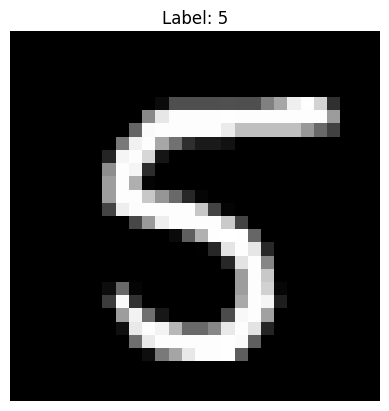

In [36]:
def visualize_samples(dataloader, num_samples=1):
    data_iter = iter(dataloader)
    images, labels = next(data_iter)

    for i in range(num_samples):
        idx = random.randint(0, len(images)-1)
        img = images[idx].squeeze()
        plt.imshow(img, cmap="gray")
        plt.title(f"Label: {labels[idx].item()}")
        plt.axis('off')
        plt.show()

visualize_samples(train_loader)

## 4) Forward Pass in Numpy []

**4.1) He initialization** []

He initialization is used to set the initial weights of neural network layers, especially those with ReLU activations. It helps maintain the variance of activations throughout the network, which improves training stability and convergence.

The formula for He initialization is:
$$
W_{ij} \sim \mathcal{N}\left(0, \frac{2}{\text{in\_dim}}\right)
$$
where $$\text{in\_dim}$$ is the number of input units to the layer. In simple terms, it means the weight matrix is initialised by sampling from a normal distribution with 0 mean and $\frac{2}{\text{in\_dim}}$ variance.

**Write a function, `he_init` function takes two arguments as input:**
- `in_dim`: The number of input units to the layer.
- `out_dim`: The number of output units (neurons) in the layer.

It returns:
- `W`: A weight matrix of shape `(out_dim, in_dim)` initialized using the He initialization method.
- `b`: A bias vector of shape `(out_dim, 1)` initialized to zeros.




In [37]:
def he_init(in_dim, out_dim):
    """He initialization"""
    std = np.sqrt(2. / in_dim)
    W = np.random.randn(out_dim, in_dim) * std
    b = np.zeros((out_dim, 1))
    return W, b

**4.2) Weight Initialization** []
- Your network should have the following architecture:
    - Input layer: 28x28 (flattened MNIST image)
    - Hidden layer 1: 256 units, ReLU activation
    - Hidden layer 2: 128 units, ReLU activation
    - Output layer: 10 units, softmax activation
- Initialise all the matrices (weights, and biases) using he_init with the correct dimensions.

In [38]:
input_dim = 28 * 28
h1_dim = 256
h2_dim = 128
output_dim = 10

# Layer 1
W1, b1 = he_init(input_dim, h1_dim)
# Layer 2
W2, b2 = he_init(h1_dim, h2_dim)
# Layer 3
W3, b3 = he_init(h2_dim, output_dim)

**4.3) Activations** []
- Write a function for ReLU
- Write a function for Softmax

In [39]:
def relu(z):
    return np.maximum(0, z)

In [40]:
def softmax(z):
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

**4.4) Forward Pass** []
- Now that you have your weights initialized, perform a forward pass on an image from the test set of  MNIST.
- Print the output probabilities and the predicted class

In [41]:
img, _ = test_dataset[random.randint(0, len(test_dataset)-1)]
x = img.numpy().reshape(-1, 1)

z1 = np.dot(W1, x) + b1
a1 = relu(z1)

z2 = np.dot(W2, a1) + b2
a2 = relu(z2)

z3 = np.dot(W3, a2) + b3
a3 = softmax(z3)

pred_class = np.argmax(a3)

print("Output probabilities:\n", a3.ravel())
print("Predicted class:", pred_class)

Output probabilities:
 [0.07534191 0.1039074  0.07367735 0.07671692 0.15841464 0.11738444
 0.09172546 0.10916535 0.05502418 0.13864236]
Predicted class: 4


## 5) Neural Networks In PyTorch []

**5.1) Helper Function** []

- Create a function `count_parameters` that takes in a model and returns its parameter count.

In [42]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

**5.2) FCNN for Digit Classification in PyTorch** []
- Create a FCNN utilising ReLU activations with more than 200,000 parameters. Print its parameter count.
- Note: You are NOT allowed to use convolutions.

In [43]:
class FCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.model(x)
        return x

model = FCNN().to(DEVICE)
print("Parameters:", count_parameters(model))

Parameters: 235146


**5.3) Hyperparameters** []
- Define the criterion, optimizer, and learning rate
- Do NOT change the number of epochs
- In a markdown cell, explain the choice of your criterion (loss function)

In [44]:
EPOCHS = 10
LR = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

Ans: 

**5.4) Training and Evaluation Functions** []
- Write a function `train` that takes in the model, dataloader, optimizer, and criterion, and trains the model for one epoch. It should return the average loss and accuracy for that epoch.
- Write a function `evaluate` that takes in the model, dataloader, and criterion, and evaluates the model on the validation or test set. It should return the average loss and accuracy.
- In a markdown cell below, also explain the use of the following functions:
    -  `optimizer.zero_grad()`
    -  `loss.backward()`
    -  `optimizer.step()`

In [45]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for data, target in loader:
        data, target = data.to(DEVICE), target.to(DEVICE)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (output.argmax(1) == target).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

In [46]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            output = model(data)
            loss = criterion(output, target)
            total_loss += loss.item()
            correct += (output.argmax(1) == target).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

Ans: 

**5.5) Training Loop** []
- Write a loop to train your model for the specified number of epochs.
- For each epoch, print the training loss, training accuracy, validation loss, and validation accuracy.
- Use your `train` and `evaluate` functions to get these values for each epoch.
- Save the model with the best validation accuracy.
- Plot the loss and accuracy curves (for both train and val set).
- Make sure to label the graphs correctly.

In [47]:
train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_acc = 0.0
best_model_state = None

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = train(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"  Train Loss: {tr_loss:.4f} | Train Acc:  {tr_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:    {val_acc:.4f}")

    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    train_accs.append(tr_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict()

torch.save(best_model_state, "best_model.pth")

Epoch 1/10
  Train Loss: 0.2167 | Train Acc:  0.9353
  Val Loss:   0.1217 | Val Acc:    0.9612
Epoch 2/10
  Train Loss: 0.0955 | Train Acc:  0.9703
  Val Loss:   0.1055 | Val Acc:    0.9687
Epoch 3/10
  Train Loss: 0.0706 | Train Acc:  0.9777
  Val Loss:   0.1069 | Val Acc:    0.9695
Epoch 4/10
  Train Loss: 0.0531 | Train Acc:  0.9832
  Val Loss:   0.1120 | Val Acc:    0.9680
Epoch 5/10
  Train Loss: 0.0427 | Train Acc:  0.9862
  Val Loss:   0.1379 | Val Acc:    0.9661
Epoch 6/10
  Train Loss: 0.0388 | Train Acc:  0.9879
  Val Loss:   0.1341 | Val Acc:    0.9693
Epoch 7/10
  Train Loss: 0.0314 | Train Acc:  0.9904
  Val Loss:   0.1245 | Val Acc:    0.9730
Epoch 8/10
  Train Loss: 0.0314 | Train Acc:  0.9910
  Val Loss:   0.1248 | Val Acc:    0.9740
Epoch 9/10
  Train Loss: 0.0280 | Train Acc:  0.9917
  Val Loss:   0.1555 | Val Acc:    0.9719
Epoch 10/10
  Train Loss: 0.0244 | Train Acc:  0.9928
  Val Loss:   0.1586 | Val Acc:    0.9744


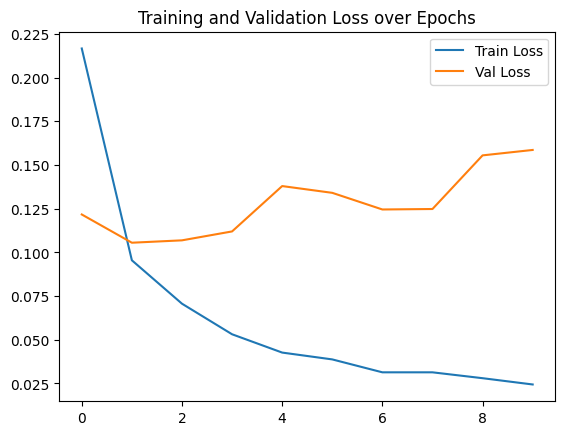

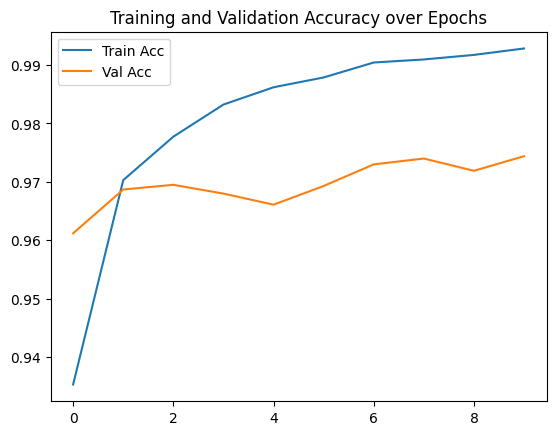

In [48]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Training and Validation Loss over Epochs")
plt.legend()
plt.show()

plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.title("Training and Validation Accuracy over Epochs")
plt.legend()
plt.show()

**5.6) Evaluation** []
- Load the model with the best validation accuracy.
- Evaluate this model on the test set and report the following:
    - Accuracy **(should be higher than 95%)**
    - F1 (macro) **(should be higher than 95%)**
    - Recall (macro) **(should be higher than 95%)**
- Print the classification report.
- Visualise the confusion matrix.
- Plot the ROC curve.
- Write a function `visualise_incorrect` that visualises the incorrectly labelled samples with their true and predicted labels.

In [49]:
model = FCNN()
model.load_state_dict(torch.load("best_model.pth"))
model = model.to(DEVICE)

In [50]:
y_true, y_pred, y_prob = [], [], []
model.eval()
with torch.no_grad():
    for data, target in tqdm(test_loader, desc="Evaluating"):
        data, target = data.to(DEVICE), target.to(DEVICE)
        output = model(data)
        prob = F.softmax(output, dim=1)
        pred = prob.argmax(1)
        y_true.extend(target.tolist())
        y_pred.extend(pred.tolist())
        y_prob.extend(prob[:,1].tolist())

print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1:", f1_score(y_true, y_pred, average="macro"))
print("Recall:", recall_score(y_true, y_pred, average="macro"))

Evaluating: 100%|██████████| 1250/1250 [00:00<00:00, 3264.34it/s]

Accuracy: 0.9761
F1: 0.9759700354318721
Recall: 0.9759472150732929


In [51]:
summary = classification_report(y_true, y_pred)
print(summary)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.97      0.97      0.97      1010
           4       0.99      0.96      0.97       982
           5       0.99      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.95      0.98      0.97       974
           9       0.96      0.96      0.96      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



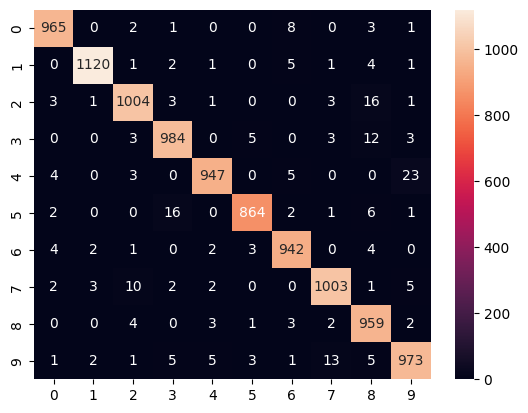

In [52]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.show()

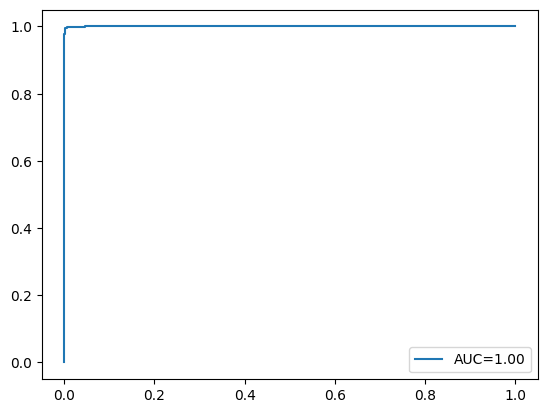

In [53]:
fpr, tpr, _ = roc_curve(np.array(y_true)==1, y_prob)
plt.plot(fpr, tpr, label=f"AUC={auc(fpr,tpr):.2f}")
plt.legend()
plt.show()

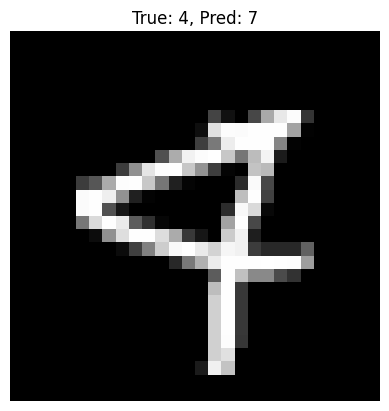

In [54]:
def visualise_incorrect(model, loader, device=DEVICE, num_samples=1):
    model.eval()
    incorrect_images = []
    true_labels = []
    pred_labels = []
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            preds = output.argmax(1)
            incorrect = preds != target
            if incorrect.any():
                incorrect_images.append(data[incorrect])
                true_labels.extend(target[incorrect].cpu().numpy())
                pred_labels.extend(preds[incorrect].cpu().numpy())
            if len(true_labels) >= num_samples:
                break
    # Flatten the list and select only the required number of samples
    images = torch.cat(incorrect_images, dim=0)[:num_samples].cpu()
    true_labels = true_labels[:num_samples]
    pred_labels = pred_labels[:num_samples]
    for i in range(len(images)):
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.title(f"True: {true_labels[i]}, Pred: {pred_labels[i]}")
        plt.axis('off')
        plt.show()

visualise_incorrect(model, val_loader)

**5.7) Out-of-distribution (OOD) Evaluation** []
- Write any digit on a piece of paper and take a photo of it.
- Load the photo and apply any processing necessary to get the image ready to be passed into the FCNN.
- Visualise the image.
- Run inference on the image and print all the output probabilities and its predicted class.
- Comment on whether the model is able to correctly predict the digit? Why or why not? 

In [57]:
# def predict_custom_image(path, model):
#     img = Image.open(path).convert("L")
#     plt.imshow(img, cmap="gray")
#     plt.axis('off')
#     plt.show()
#     img = img.resize((28, 28), resample=Image.BILINEAR)
#     img = transform(img).unsqueeze(0)
#     img = img.to(DEVICE)
#     output = model(img)
#     prob = F.softmax(output, dim=1)
#     print("Probabilities:", prob.detach().cpu().numpy())
#     pred = prob.argmax(1).item()
#     print("Predicted class:", pred)

# predict_custom_image("IMG_3995.DNG", model)

Ans:

## 6) Data Pruning []

**6.1) Smaller FCNN for Digit Classification in PyTorch** []
- Create a (smaller) FCNN utilising ReLU activations with less than 110,000 parameters. Print its parameter count.
- Note: You are NOT allowed to use convolutions.

In [58]:
class SmallerFCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.model(x)
        return x

smaller_model = SmallerFCNN().to(DEVICE)
print("Parameters:", count_parameters(smaller_model))

Parameters: 109386


**6.2) Hyperparameters** []
- Define the criterion, optimizer, and learning rate
- Do NOT change the number of epochs

In [59]:
EPOCHS = 20
LR = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(smaller_model.parameters(), lr=LR)

**6.3) Confidence Selection (Note: This function is already provided to you below)** 

- `get_bottomk` returns the indices of the K samples in a dataset for which the model is least confident about the correct class.
- The function takes as input:
    - `model`: the trained model
    - `loader`: a DataLoader for the dataset
    - `K`: the number of least confident samples to select
- For each sample, it computes the probability assigned to the ground-truth class (after applying softmax).
- Returns the indices of the K samples with the lowest such probabilities.
- This essentially returns the *hardest* samples since the model is unsure about them.

In [60]:
def get_bottomk(model, loader, K):
    model.eval()
    p_true_all, idx_all = [], []
    start = 0

    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(loader):
            data, target = data.to(DEVICE), target.to(DEVICE)
            out = model(data)
            probs = F.softmax(out, dim=1)
            p_true = probs[torch.arange(len(target)), target].cpu().numpy()

            p_true_all.extend(p_true)
            idx_all.extend(range(start, start + len(target)))
            start += len(target)

    p_true_all = np.array(p_true_all)
    idx_all = np.array(idx_all)

    order = np.argsort(p_true_all)
    bottomk_indices = idx_all[order[:K]]
    return bottomk_indices

**6.4) Create a dataloader** []
- Using the `get_bottomk` function get the bottom `10,000` samples from the `train_loader`
- Use these indices to create a `bottomk_dataloader`, with the help of the `Subset` class

In [61]:
bottomk_idx = get_bottomk(model, train_loader, K=10000)
bottomk_loader = DataLoader(Subset(train_ds, bottomk_idx), batch_size=8, shuffle=True)

**6.5) Training Loop** []
- Write a loop to train your model for the specified number of epochs.
- For each epoch, print the training loss, training accuracy, validation loss, and validation accuracy.
- Use your previously defined `train` and `evaluate` functions to get these values for each epoch.

In [62]:
train_losses, val_losses, train_accs, val_accs = [], [], [], []
for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = train(smaller_model, bottomk_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(smaller_model, val_loader, criterion)

    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"  Train Loss: {tr_loss:.4f} | Train Acc:  {tr_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:    {val_acc:.4f}")

    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    train_accs.append(tr_acc)
    val_accs.append(val_acc)

Epoch 1/20
  Train Loss: 0.4838 | Train Acc:  0.8546
  Val Loss:   0.2758 | Val Acc:    0.9151
Epoch 2/20
  Train Loss: 0.2117 | Train Acc:  0.9353
  Val Loss:   0.2459 | Val Acc:    0.9257
Epoch 3/20
  Train Loss: 0.1454 | Train Acc:  0.9549
  Val Loss:   0.2051 | Val Acc:    0.9367
Epoch 4/20
  Train Loss: 0.1073 | Train Acc:  0.9669
  Val Loss:   0.2274 | Val Acc:    0.9338
Epoch 5/20
  Train Loss: 0.0752 | Train Acc:  0.9751
  Val Loss:   0.1697 | Val Acc:    0.9485
Epoch 6/20
  Train Loss: 0.0596 | Train Acc:  0.9819
  Val Loss:   0.1915 | Val Acc:    0.9471
Epoch 7/20
  Train Loss: 0.0431 | Train Acc:  0.9872
  Val Loss:   0.2133 | Val Acc:    0.9454
Epoch 8/20
  Train Loss: 0.0296 | Train Acc:  0.9908
  Val Loss:   0.1915 | Val Acc:    0.9533
Epoch 9/20
  Train Loss: 0.0375 | Train Acc:  0.9867
  Val Loss:   0.2092 | Val Acc:    0.9488
Epoch 10/20
  Train Loss: 0.0209 | Train Acc:  0.9927
  Val Loss:   0.3371 | Val Acc:    0.9281
Epoch 11/20
  Train Loss: 0.0338 | Train Acc:  0.

**6.6) Evaluation** []
- Evaluate this smaller model on the test set and report the following:
    - Accuracy **(should be higher than 95%)**
    - F1 (macro) **(should be higher than 95%)**
    - Recall (macro) **(should be higher than 95%)**
- Print the classification report.
- Visualise the confusion matrix.
- Comment on this model's performance in comparison with the larger model. Did it perform better or worse? Why?

In [63]:
y_true, y_pred, y_prob = [], [], []
smaller_model.eval()
with torch.no_grad():
    for data, target in tqdm(test_loader, desc="Evaluating"):
        data, target = data.to(DEVICE), target.to(DEVICE)
        output = smaller_model(data)
        prob = F.softmax(output, dim=1)
        pred = prob.argmax(1)
        y_true.extend(target.tolist())
        y_pred.extend(pred.tolist())
        y_prob.extend(prob[:,1].tolist())

print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1:", f1_score(y_true, y_pred, average="macro"))
print("Recall:", recall_score(y_true, y_pred, average="macro"))

Evaluating: 100%|██████████| 1250/1250 [00:00<00:00, 3484.91it/s]

Accuracy: 0.9438
F1: 0.943738101219104
Recall: 0.9438624837283671


In [64]:
summary = classification_report(y_true, y_pred)
print(summary)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       980
           1       0.99      0.95      0.97      1135
           2       0.96      0.93      0.95      1032
           3       0.97      0.92      0.95      1010
           4       0.95      0.95      0.95       982
           5       0.94      0.92      0.93       892
           6       0.96      0.96      0.96       958
           7       0.98      0.89      0.93      1028
           8       0.85      0.96      0.90       974
           9       0.88      0.97      0.92      1009

    accuracy                           0.94     10000
   macro avg       0.95      0.94      0.94     10000
weighted avg       0.95      0.94      0.94     10000



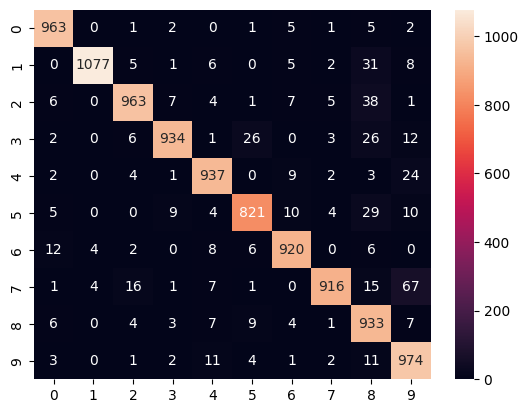

In [65]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.show()

Ans: 

# Graduate Question — Implement the Backward Pass 
## [6 marks Activations + 14 marks Backward Pass = 20marks]
This task is **mandatory for GRADUATE STUDENTS** and will be graded. Undergraduate students may skip this task, as it is not graded for them.  
In this exercise, you will implement **backpropagation** for a lightweight fully connected neural network using only **NumPy**.   The goal is to compute gradients of weights and biases for each layer using the **chain rule** of calculus.  
Note: caches are not required for this implementation
[6marks Activations + 14marks Backward Pass]


In [70]:
# ---- Activation derivatives ----
def dsigmoid(a):
    return a * (1 - a)

def dtanh(a):
    return 1 - a**2

def drelu(z):
    return (z > 0).astype(z.dtype)

# ---- Backward Pass (TO BE IMPLEMENTED) ----
def backward(W, b, A, Z, Y, activations):
    """
    Compute gradients for a fully-connected MLP (no caches passed around).
    Inputs:
        W, b  : lists of weights/biases, indexed 1..L
        A, Z  : lists of activations and pre-activations, A[0]=X^T, up to A[L]
        Y     : (m,1) labels
        activations: list of names per layer, e.g. [None, 'tanh', 'sigmoid']
    Returns:
        dW, db: lists of gradients, indexed 1..L
    """
    m = Y.shape[0]
    L = len(W) - 1
    dW = [None] * (L + 1)
    db = [None] * (L + 1)

    # Output layer: sigmoid + BCE => dZ^L = A^L - Y^T
    dZ = A[L] - Y.T  # shapes: (n_L, m) and (n_L, m)

    for l in range(L, 0, -1):
        A_prev = A[l-1]                          # (n_{l-1}, m)
        dW[l] = (dZ @ A_prev.T) / m              # (n_l, n_{l-1})
        db[l] = dZ.mean(axis=1, keepdims=True)   # (n_l, 1)

        if l > 1:
            dA_prev = W[l].T @ dZ                # (n_{l-1}, m)
            act = activations[l]
            # derivative at layer l-1
            if activations[l-1] == "tanh":
                gprime = 1 - A[l-1]**2           # dtanh from A
            elif activations[l-1] == "relu":
                gprime = (Z[l-1] > 0).astype(Z[l-1].dtype)
            elif activations[l-1] == "sigmoid":
                gprime = A[l-1] * (1 - A[l-1])   # dsigmoid from A
            else:
                raise ValueError(f"Unknown activation '{activations[l-1]}'")
            dZ = dA_prev * gprime

    return dW, db


## Backprop Testing (Just run the code block below without changing anything)

In [ ]:
np.random.seed(0)
m = 4
X = np.random.randn(m,2)
Y = (np.random.rand(m,1) > 0.5).astype(int)

W = [None, np.random.randn(3,2)*0.1, np.random.randn(1,3)*0.1]
b = [None, np.zeros((3,1)), np.zeros((1,1))]
Z = [None,
     np.random.randn(3,m),
     np.random.randn(1,m)]
A = [X.T,
     np.tanh(Z[1]),
     1/(1+np.exp(-Z[2]))]

activations = [None, "tanh", "sigmoid"]

dW, db = backward(W, b, A, Z, Y, activations)

print("dW[1] shape:", None if dW[1] is None else dW[1].shape)
print("db[1] shape:", None if db[1] is None else db[1].shape)
print("dW[2] shape:", None if dW[2] is None else dW[2].shape)
print("db[2] shape:", None if db[2] is None else db[2].shape)

# Expected:
#   dW[1] -> (3,2)
#   db[1] -> (3,1)
#   dW[2] -> (1,3)
#   db[2] -> (1,1)

dW[1] shape: (3, 2)
db[1] shape: (3, 1)
dW[2] shape: (1, 3)
db[2] shape: (1, 1)
